Winner:  981 Losers:  969
10000 10364
Broke percentage: 6.0


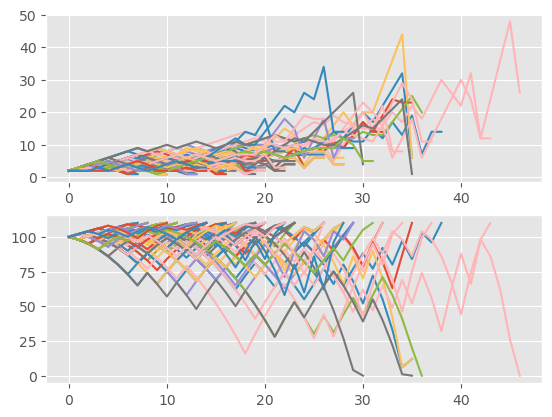

In [5]:
import random
import time
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import style

style.use("ggplot")

broke_count = 0

totalFunded = 0
totalEnding = 0

wins = 0
losses = 0

def Labouchere():
    global broke_count
    global totalFunded
    global totalEnding
    global wins
    global losses

    starting_funds = 100

    totalFunded += starting_funds
    
    goal = 10
    system = [1,1,1,1,1,1,1,1,1,1]
    #system = [1,2,2,3,2]

    profit = 0

    current_funds = starting_funds

    wagerSizes = []
    plot_funds = []

    not_broke = True 

    while profit < goal and not_broke: 
        if len(system) > 1: 
            size = system[0]+system[-1]
            wagerSizes.append(size)
            plot_funds.append(current_funds)

        else: 
            size = system[0]
            wagerSizes.append(size)
            plot_funds.append(current_funds)

        if current_funds <= 0: 
            not_broke = False
            broke_count += 1

        elif current_funds - size <= 0: 
            size = current_funds
            not_broke = False
            broke_count += 1

        dice = random.randrange(1, 101) 

        if dice < 51:
            losses += 1
            system.append(size)
            current_funds -= size
            profit = current_funds - starting_funds

        else: 
            wins += 1
            current_funds += size
            profit = current_funds - starting_funds

            if profit != goal: 
                try:
                    del system[0]
                    del system[-1]
                except:
                    pass

    wagerSizes.append(size)
    plot_funds.append(current_funds)

    totalEnding += current_funds

    s1.plot(wagerSizes)
    s2.plot(plot_funds)

f = plt.figure()
s1 = f.add_subplot(211)
s2 = f.add_subplot(212)

sample_size = 100

for x in range(sample_size):
    Labouchere()
    
print('Winner: ', wins, 'Losers: ', losses)
print(totalFunded, totalEnding)
print('Broke percentage:', ((float(broke_count)/sample_size))*100.0)

plt.show()